#AQFT - comparativo entre AQFT e valor esperado QFT

- pontos a investigar

- probabilidade dos picos 
- a distribuição do shor exata se todos os picos estão associados a j/r
- impacto do na probabilidade
- tirar  da probabilidade dos picos quando o j não serve.


In [1]:
#!/usr/bin/env -S python3 -u 
"""
usage:aqft.ipynb

options:
    None

description:
    This notebook contains code to test the precision difference between AQFT and QFT. 

"""
__author__      = 'Eduardo Marsola do Nascimento'
__copyright__   = 'Copyright 2026-04-12'
__credits__     = ''
__license__     = 'MIT'
__version__     = '1.00'
__maintainer__  = ''
__email__       = ''
__status__      = 'Production'
__printdebug__  = False


"""
to prepare the environment
1. create a virtual environment: 
    python -m venv ./venv
2. upgrade pip: 
    python -m pip install --upgrade pip
3. install libraries:
## installing NumPy and MatPlotLib
    pip install numpy
    pip install matplotlib
## installing PyCryptodome
    pip install pycryptodome
## installing Qiskit
    pip install qiskit
    pip install qiskit-aer
    pip install qiskit-ibm-runtime
    pip install pylatexenc
"""

!pip install numpy
!pip install matplotlib
!pip install pycryptodome
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pylatexenc
!pip install mpmath


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [1]:

## carrega bibliotecas
import qiskit
import Crypto
import decimal

from decimal import *

from datetime import datetime
from Crypto.Util import number
from Crypto.Random import random
import matplotlib.pyplot as plt
import numpy as np
import mpmath
from mpmath import mp
import math

from fractions import Fraction

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


print(f'qiskit.__version__={qiskit.__version__}')
print(f'numpy.__version__={np.__version__}')
print(f'decimal.__version__={decimal.__version__}')
print(f'Crypto.__version__={Crypto.__version__}')
print(f'mpmath.__version__={mpmath.__version__}')

mp.dps=100

qiskit.__version__=2.3.1
numpy.__version__=2.3.4
decimal.__version__=1.70
Crypto.__version__=3.23.0
mpmath.__version__=1.4.1


# gera a AQFT - gerado com auxilio do Anthropic Claude

In [5]:
#### aplica o shor para fatorar um número composto N usando a base a
def return_order(N: int, a: int) -> int:
    r = 1
    power = a % N
    while power != 1 and r <= N:
        power = (power * a) % N
        r += 1
    return r

def shors_algorithm(N: int ) -> int:
    """Implementação simplificada do algoritmo de Shor para fatoração de N usando a base a."""
    MAX_TENTATIVAS = N
    tentativas = 0

    while tentativas < MAX_TENTATIVAS:
        tentativas += 1
        # Passo 1: Seleciona um a aleatório entre 2 e N-1 e coprimo com N
        a = random.randint(2, N - 1)
        print(f"Tentativa {tentativas}: a = {a}")
        if math.gcd(a, N) != 1:
            print(f"{a} não é coprimo com {N}. Encontrado fator trivial: {math.gcd(a, N)}")
            continue
        
        # Passo 2: Encontrar a ordem r de a módulo N
        r = return_order(N, a)
        if r % 2 != 0:
            print(f"A ordem r = {r} é ímpar. Tentando outro valor de a.")
    
        ar_half = pow(a, r // 2, N)
        if ar_half == N - 1:
            print(f"a^(r/2) é congruente a -1 mod N. Tente outro valor de a.")
            continue
        
        # Passo 4: Calcular os fatores candidatos
        factor1 = math.gcd(ar_half - 1, N)
        factor2 = math.gcd(ar_half + 1, N)
        
        # Verificar se os fatores são válidos
        if factor1 in [1, N] or factor2 in [1, N]:
            print(f"Fatores triviais encontrados. Tente outro valor de a.")
            continue
        
        return factor1, factor2, a, r
    print(f"Falha ao encontrar fatores não triviais após {MAX_TENTATIVAS} tentativas.")
    

def find_shor_example(nBits=16):
    # Gerar um número composto N para fatorar
    p = number.getPrime(nBits // 2)
    q = number.getPrime(nBits // 2 + nBits % 2)
    N = p * q
    print(f"N = {N} (fatores: {p}, {q})")
    
    # Executar o algoritmo de Shor
    factor1, factor2, a, r = shors_algorithm(N)
    if factor1 is not None:
        print(f"N={N}, a={a}, r={r}, p={factor1}, q={factor2}")  
    else:
        print("Nenhum fator encontrado.")

find_shor_example(nBits=20)
# exemplos
# 16 bits
# N=29737, a=9094, r=14690, p=131, q=227
# N=34717, a=29699, r=8584, p=149, q=233
# N=27221, a=4888, r=13446, p=163, q=167
# N=60491, a=44565, r=120, p=251, q=241
# N=32437, a=23138, r=594, p=163, q=199
# N=21509, a=15983, r=5304, p=157, q=137
# N=26123, a=10452, r=516, p=151, q=173
# N=45901, a=12354, r=11368, p=197, q=233
# N=33389, a=28255, r=8256, p=173, q=193
# N=41693, a=10464, r=3440, p=173, q=241
# 
# 5 bits
# N=35, a=32, r=12, p=7, q=5
# N=21, a=11, r=6, p=7, q=3
# N=15, a=8, r=4, p=3, q=5
#
# 20 bits
# N=525323, a=235635, r=130962, p=599, q=877

N = 578129 (fatores: 617, 937)
Tentativa 1: a = 420468
a^(r/2) é congruente a -1 mod N. Tente outro valor de a.
Tentativa 2: a = 269411
a^(r/2) é congruente a -1 mod N. Tente outro valor de a.
Tentativa 3: a = 70312
N=578129, a=70312, r=72072, p=937, q=617


#Functions with QISKIT

Exemplo: N=21, a=11, r=6, p=7, q=3, L=10, phi=2*pi*0.1666666666666667
Circuito AQFT† - qiskit - L=10, m=5:
State not normalized: norm=1.0000000000000013
IQFT probabilities:
0000000000 (0): 0.1666666666666671
0000000001 (1): 0.0000000000000000
0000000010 (2): 0.0000000000000000
0000000011 (3): 0.0000000000000000
0000000100 (4): 0.0000000000000000
0000000101 (5): 0.0000000000000000
0000000110 (6): 0.0000000000000000
0000000111 (7): 0.0000000000000000
0000001000 (8): 0.0000000000000000
0000001001 (9): 0.0000000000000000
0000001010 (10): 0.0000000000000000
0000001011 (11): 0.0000000000000000
0000001100 (12): 0.0000000000000000
0000001101 (13): 0.0000000000000000
0000001110 (14): 0.0000000000000000
0000001111 (15): 0.0000000000000000
0000010000 (16): 0.0000000000000000
0000010001 (17): 0.0000000000000000
0000010010 (18): 0.0000000000000000
0000010011 (19): 0.0000000000000000
0000010100 (20): 0.0000000000000000
0000010101 (21): 0.0000000000000000
0000010110 (22): 0.0000000000000000
000001011

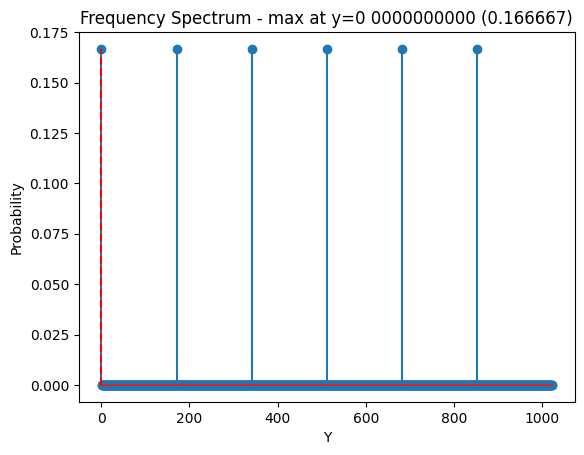

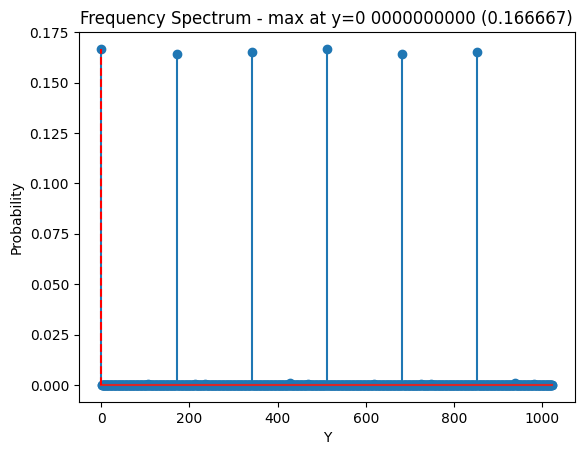

In [ ]:

def aqft_dagger(L: int, m: int) -> QuantumCircuit:
    """
    AQFT inversa truncada em L qubits.
    Mantém apenas rotações controladas até distância m.
    Para m >= L, coincide com a IQFT usual (sem swaps explícitos, mas com
    correção de bit-reversal na leitura).
    ### Original function using QISKIT
    """
    qc = QuantumCircuit(L, name=f"AQFT†(L={L},m={m})")
    # Implementação padrão da IQFT sem swaps finais
    for j in range(L):
        # rotações controladas truncadas
        start_k = max(0, j - m + 1)
        for k in range(start_k, j):
            angle = -np.pi / (2 ** (j - k))
            qc.cp(angle, k, j)
        qc.h(j)
    return qc

def normalize(psi):
    norm = np.sqrt(sum(abs(a)**2 for a in psi))
    return [a / norm for a in psi]


""""
def define_initial_state_for_order(r: int, L: int ) -> Statevector:
    #Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    #(1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    
    M = 2 ** L
    phi=1/r
    amps = np.zeros(M, dtype=complex)
    for i in range(1, r+1):
        phi = i/r
        amps += np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    amps /= r
    return Statevector(amps)
"""
"""

def define_initial_state_for_order(r: int, L: int) -> Statevector:
    M = 2 ** L
    x = np.arange(M)
    k = np.arange(r)
    # shape (M, r) phase matrix, then sum over k axis
    phases = np.exp(2j * np.pi * np.outer(x, k) / r)
    amps = phases.sum(axis=1) / np.sqrt(r * M)

    norm = np.sqrt(np.sum(np.abs(amps)**2))
    if abs(norm - 1.0) < 1e-9:
        print(f"State not normalized: norm={norm:.16f}")
    amps /= norm

    return Statevector(amps)
"""
def define_initial_state_for_order(r: int, L: int) -> Statevector:
    M = 2 ** L
    # Desired output: r equal peaks at natural positions round(k*M/r)
    peak_positions = np.array([round(k * M / r) % M for k in range(r)])
    # QFT of desired output → required input in natural ordering
    x = np.arange(M)
    phases = np.exp(2j * np.pi * np.outer(x, peak_positions) / M)
    input_natural = phases.sum(axis=1) / np.sqrt(r * M)
    # Bit-reverse the amplitudes to match Qiskit's little-endian convention
    amps = np.array([input_natural[bit_reverse(i, L)] for i in range(M)])
    norm = np.sqrt(np.sum(np.abs(amps)**2))
    if abs(norm - 1.0) < 1e-9:
        print(f"State not normalized: norm={norm:.16f}")
    amps /= norm
    return Statevector(amps)

def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out

def reorder_probabilities(probs, L):
    reordered_probs = np.zeros_like(probs)
    for y, p in enumerate(probs):
        reordered_probs[bit_reverse(y, L)] = p
    return reordered_probs

def aqft_example(N, a, r, p, q, L=None, m=5):
    if L is None:
        L = (int(math.log2(N))+1)*2+1
    phi = ((1)/r)
    m=5
    # gera AQFT† para diferentes m
    print(f"Exemplo: N={N}, a={a}, r={r}, p={p}, q={q}, L={L}, phi=2*pi*{phi:.16f}")

    print (f'Circuito AQFT† - qiskit - L={L}, m={m}:')
    # IQFT
    qc = aqft_dagger(L, L)
    sv_initial = define_initial_state_for_order(r, L)
    sv_final = sv_initial.evolve(qc)
    prob_iqft = sv_final.probabilities()
    #prob_iqft = reorder_probabilities(prob_iqft, L) 
    print("IQFT probabilities:")

    peak_prob = 0
    expected_peak = np.round(np.arange(2**L/r,2**L,2**L/r)).astype(int)
    for i, p in enumerate(prob_iqft):
        print(f'{i:0{L}b} ({i}): {float(p):.16f}')
        if i in expected_peak:
            peak_prob += p
            
    print(f'total probability: {float(sum(prob_iqft)):.16f} ')
    print(f'expected peaks at: {expected_peak} with total probability {float(peak_prob):.16f}')
    print(f'')


    # AQFT with truncation m
    qc = aqft_dagger(L, m)
    sv_initial = define_initial_state_for_order(r, L)
    sv_final = sv_initial.evolve(qc)
    prob_aqft = sv_final.probabilities()
    #prob_aqft = reorder_probabilities(prob_aqft, L) 
    print(f"AQFT probabilities (m={m}):")
    
    peak_prob = 0
    expected_peak = np.round(np.arange(2**L/r,2**L,2**L/r)).astype(int)
    for i, p in enumerate(prob_aqft):
        print(f'{i:0{L}b} ({i}): {float(p):.16f}')
        if i in expected_peak:
            peak_prob += p
    print(f'total probability: {float(sum(prob_aqft)):.16f} ')
    print(f'expected peaks at: {expected_peak} with total probability {float(peak_prob):.16f}')
    print(f'')


    error = sum(mp.fabs(prob_iqft[i] - prob_aqft[i]) for i in range(len(prob_iqft)))
    print(f"\nTotal error (L1 norm): {float(error):.16f}")
    print(f'')

    i=0
    for probs in [prob_iqft, prob_aqft]:
        ys = np.arange(len(probs))
        peak_y = np.argmax(probs)
        peak_value = np.max(probs)
        plt.figure()
        plt.stem(ys, probs)
        plt.xlabel("Y")
        plt.ylabel("Probability")
        plt.title(f"Frequency Spectrum - max at y={peak_y} {peak_y:0{L}b} ({float(peak_value):.6f})")
        plt.vlines(peak_y, 0, peak_value,colors='r', linestyles='dashed', label='Peak')
        plt.savefig(f'img/probability_qiskit_{'IQFT' if i == 0 else 'AQFT'}_L_{L}.png')
        #plt.show()
        i+=1
    return

if __name__ == "__main__":
    aqft_example(N=21, a=11, r=6, p=7, q=3, L=10, m=5)
    #aqft_example(N=15, a=8, r=4, p=3, q=5)
    #aqft_example(N=29737, a=9094, r=14690, p=131, q=227)
    #aqft_example(N=26123, a=10452, r=516, p=151, q=173)


#functions without QISKIT

Exemplo: N=21, a=11, r=6, p=7, q=3, L=5, phi=2*pi*0.1666666666666667
IQFT probabilities:
00000: 0.1875000000000000
00001: 0.0000000000000000
00010: 0.0104166666666667
00011: 0.0104166666666667
00100: 0.0030509710293068
00101: 0.0177823623040265
00110: 0.0177823623040265
00111: 0.0030509710293068
01000: 0.0024711559589238
01001: 0.0011032789421972
01010: 0.1168040797086750
01011: 0.0046214853902039
01100: 0.0046214853902039
01101: 0.1168040797086750
01110: 0.0011032789421972
01111: 0.0024711559589238
10000: 0.0594563748140456
10001: 0.0054711286669391
10010: 0.0008920661882395
10011: 0.0002548652318969
10100: 0.0016231897966130
10101: 0.1673295537954337
10110: 0.0089469370380451
10111: 0.0060258844687872
11000: 0.0060258844687872
11001: 0.0089469370380451
11010: 0.1673295537954337
11011: 0.0016231897966130
11100: 0.0002548652318969
11101: 0.0008920661882395
11110: 0.0054711286669391
11111: 0.0594563748140456
total probability: 1.0000000000000000 


AQFT probabilities (m=3):
00000: 0.187

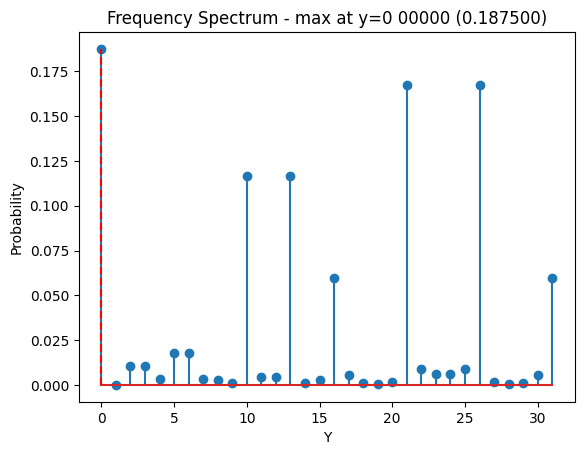

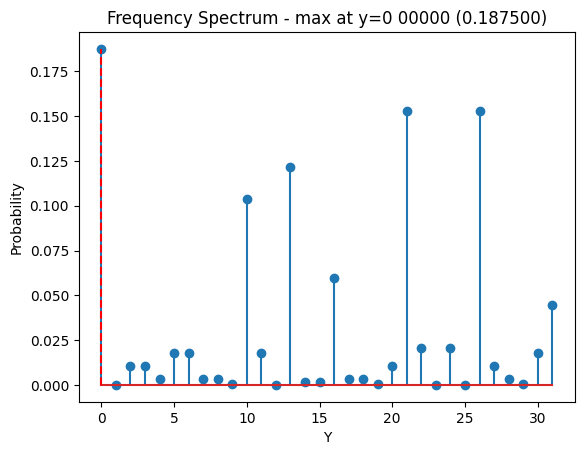

In [ ]:

def normalize(psi):
    norm = mp.sqrt(sum(abs(a)**2 for a in psi))
    return [a / norm for a in psi]


def apply_hadamard(psi, qubit, n):
    """Apply H to qubit"""
    new_psi = psi.copy()
    N = len(psi)

    for i in range(N):
        if ((i >> qubit) & 1) == 0:
            j = i | (1 << qubit)

            a = psi[i]
            b = psi[j]

            new_psi[i] = (a + b) / mp.sqrt(2)
            new_psi[j] = (a - b) / mp.sqrt(2)

    return new_psi

def apply_cp(psi, control, target, theta):
    """Apply controlled phase"""
    new_psi = psi.copy()
    N = len(psi)

    for i in range(N):
        if ((i >> control) & 1) and ((i >> target) & 1):
            new_psi[i] *= mp.exp(1j * theta)

    return new_psi

# -----------------------------------
# AQFT dagger (your exact structure)
# -----------------------------------
def aqft_dagger_state(psi, L, m):
    psi = psi.copy()

    for j in range(L):
        start_k = max(0, j - m + 1)
        # controlled phase rotations
        for k in range(start_k, j):
            angle = -mp.pi / (2 ** (j - k))
            psi = apply_cp(psi, k, j, angle)

        # Hadamard
        psi = apply_hadamard(psi, j, L)

    return psi

def iqft_state(psi, L):
    return aqft_dagger_state(psi, L, m=L)



# -----------------------------------
# Probabilities
# -----------------------------------
def probabilities(psi):
    return [abs(a)**2 for a in psi]


def define_initial_state_for_order(r: int, L: int ):
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    v_exp = np.vectorize(mp.exp)
    M = 2 ** L
    amps = np.array([mp.mpc(0)]*M)
    for i in range(r):
        phi = mp.mpc(i)/mp.mpc(r)
        amps += v_exp(2j * mp.pi * phi * np.arange(M)) / mp.sqrt(M)
    #amps /= r  # Normaliza o vetor de estado
    return amps

def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out

def reorder_probabilities(probs, L):
    reordered_probs = np.zeros_like(probs)
    for y, p in enumerate(probs):
        reordered_probs[bit_reverse(y, L)] = p
    return reordered_probs

def aqft_example(N, a, r, p, q):
    L = int(mp.log(N, 2)) + 1
    phi = (1/r)
    M = 2 ** L
    m = 5

    print(f"Exemplo: N={N}, a={a}, r={r}, p={p}, q={q}, L={L}, phi=2*pi*{phi:.16f}")

    # Example: |011>
    #psi = [mp.mpc(0) for _ in range(M)]
    #psi[3] = mp.mpc(1)
    psi = define_initial_state_for_order(r, L)
    psi = normalize(psi)

    # IQFT
    psi_iqft = iqft_state(psi, L)
    prob_iqft = probabilities(psi_iqft)
    prob_iqft = reorder_probabilities(prob_iqft, L) 
    peak_prob = 0
    expected_peak = np.round(np.arange(2**L/r,2**L,2**L/r)).astype(int)
    print("IQFT probabilities:")
    for i, p in enumerate(prob_iqft):
        print(f'{i:0{L}b}: {float(p):.16f}')
        if i in expected_peak:
            peak_prob += p
    print(f'total probability: {float(sum(prob_iqft)):.16f} ')
    print(f'expected peaks at: {expected_peak} with total probability {float(peak_prob):.16f}')
    print(f'')

    # AQFT with truncation m
    psi_aqft = aqft_dagger_state(psi, L, m)
    prob_aqft = probabilities(psi_aqft)
    prob_aqft = reorder_probabilities(prob_aqft, L) 
    
    peak_prob = 0
    expected_peak = np.round(np.arange(2**L/r,2**L,2**L/r)).astype(int)
    print(f"\nAQFT probabilities (m={m}):")
    for i, p in enumerate(prob_aqft):
        print(f'{i:0{L}b}: {float(p):.16f}')
        if i in expected_peak:
            peak_prob += p
    print(f'total probability: {float(sum(prob_aqft)):.16f} ')
    print(f'expected peaks at: {expected_peak} with total probability {float(peak_prob):.16f}')
    print(f'')

    error = sum(mp.fabs(prob_iqft[i] - prob_aqft[i]) for i in range(len(prob_iqft)))
    print(f"\nTotal error (L1 norm): {float(error):.16f}")
    print(f'')

    i=0
    for probs in [prob_iqft, prob_aqft]:
        ys = np.arange(len(probs))
        peak_y = np.argmax(probs)
        peak_value = np.max(probs)
        plt.figure()
        plt.stem(ys, probs)
        plt.xlabel("Y")
        plt.ylabel("Probability")
        plt.title(f"Frequency Spectrum - max at y={peak_y} {peak_y:0{L}b} ({float(peak_value):.6f})")
        plt.vlines(peak_y, 0, peak_value,colors='r', linestyles='dashed', label='Peak')
        plt.savefig(f'img/probability_mpmath_{'IQFT' if i == 0 else 'AQFT'}_L_{L}.png')
        #plt.show()
        i+=1
    return
# -----------------------------------
# Example
# -----------------------------------
if __name__ == "__main__":

    #aqft_example(N=15, a=8, r=4, p=3, q=5)
    #aqft_example(N=21, a=11, r=6, p=7, q=3)
    #aqft_example(N=29737, a=9094, r=14690, p=131, q=227)
    aqft_example(N=26123, a=10452, r=516, p=151, q=173)
